1. Imports & Environment Setup

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Set plotting style

In [ ]:
sns.set_theme(style="whitegrid")

2. Data Loading

In [ ]:
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame.copy()

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


3. Exploratory Data Analysis (EDA)

In [ ]:
print("\nMissing Values Check:")
print(df.isnull().sum())


Missing Values Check:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
print("\nSummary Statistics:")
print(df.describe().T)


Summary Statistics:
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.333333    1.006079   
Population   20640.0  1425.476744  1132.462122    3.000000  787.000000   
AveOccup     20640.0     3.070655    10.386050    0.692308    2.429741   
Latitude     20640.0    35.631861     2.135952   32.540000   33.930000   
Longitude    20640.0  -119.569704     2.003532 -124.350000 -121.800000   
MedHouseVal  20640.0     2.068558     1.153956    0.149990    1.196000   

                     50%          75%           max  
MedInc          3.534800     4.743250     15.000100  
HouseAge       29.000000    37.000000     52.000000  
AveRooms        5.229129     6.052381    141.909091  
AveBedrms       1.0487

Correlation Heatmap

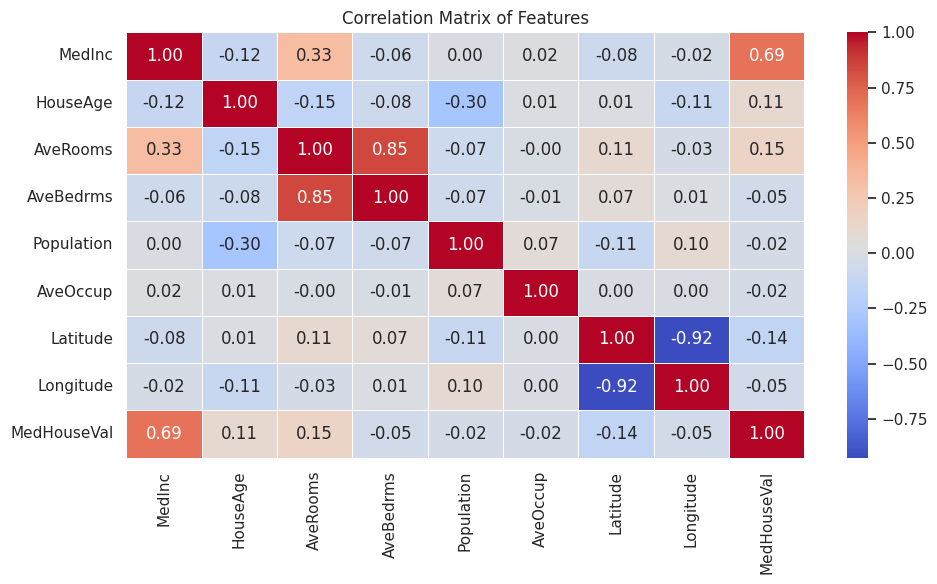

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()

Distribution of Target Variable

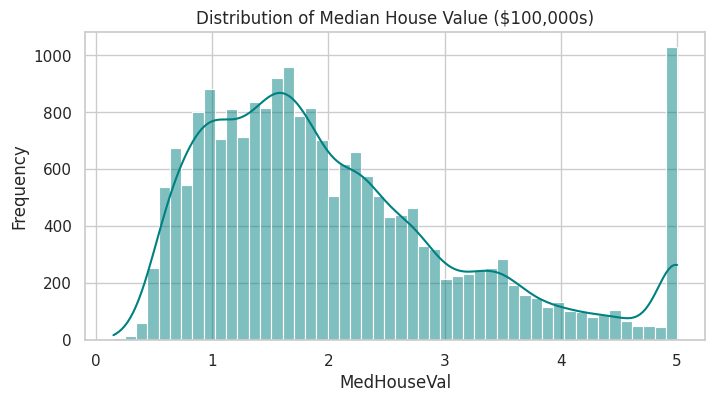

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["MedHouseVal"], bins=50, kde=True, color="teal")
plt.title("Distribution of Median House Value ($100,000s)")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.show()

4. Data Preprocessing & Splitting

In [ ]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


5. Model Training & Evaluation

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation Metrics

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score:                       {r2:.4f}")


--- Model Performance ---
Mean Absolute Error (MAE):     0.5332
Root Mean Squared Error (RMSE): 0.7456
R² Score:                       0.5758


Feature Coefficients

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)
print("\nFeature Coefficients:")
print(coef_df)


Feature Coefficients:
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


6. Evaluation Plots

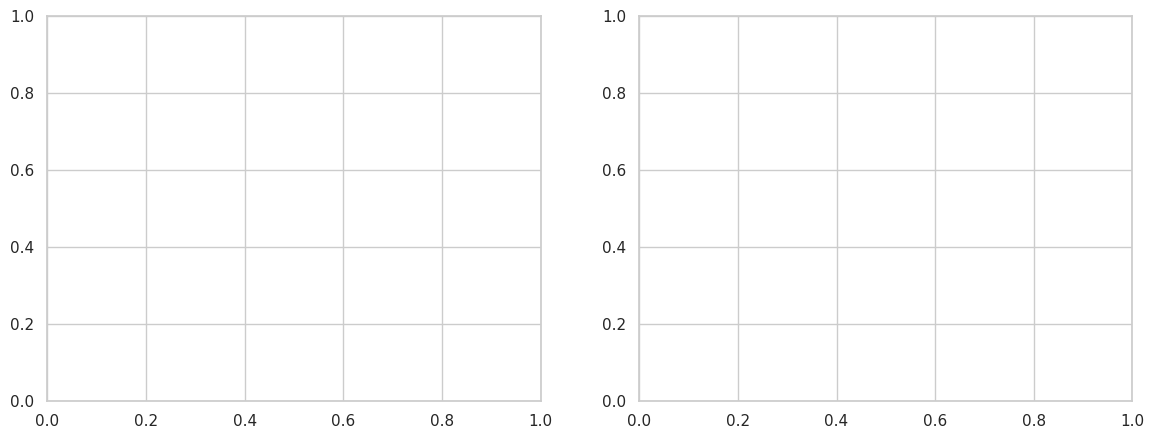

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

Plot 1: Actual vs Predicted

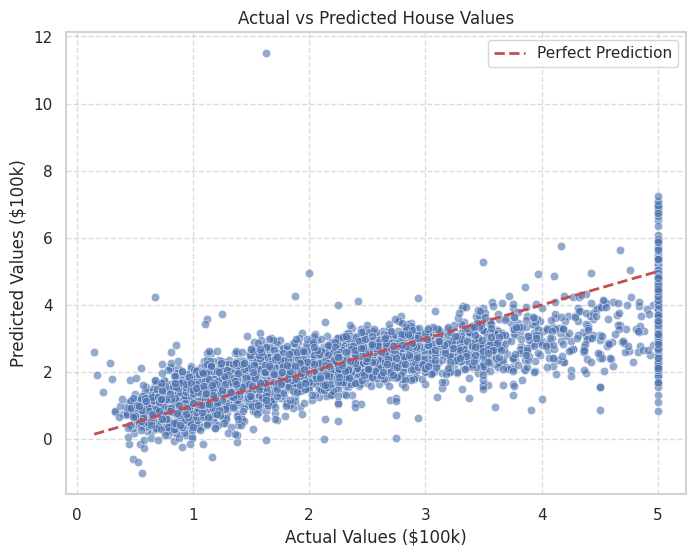

In [ ]:
ax[0].scatter(y_test, y_pred, alpha=0.3, color="royalblue", edgecolors="none")
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
ax[0].set_xlabel("Actual Values ($100k)")
ax[0].set_ylabel("Predicted Values ($100k)")
ax[0].set_title("Actual vs Predicted House Values")
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual', y='Predicted', data=comparison_df, alpha=0.6)
plt.plot([comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         [comparison_df['Actual'].min(), comparison_df['Actual'].max()],
         'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted House Values')
plt.xlabel('Actual Values ($100k)')
plt.ylabel('Predicted Values ($100k)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Plot 2: Residuals Distribution

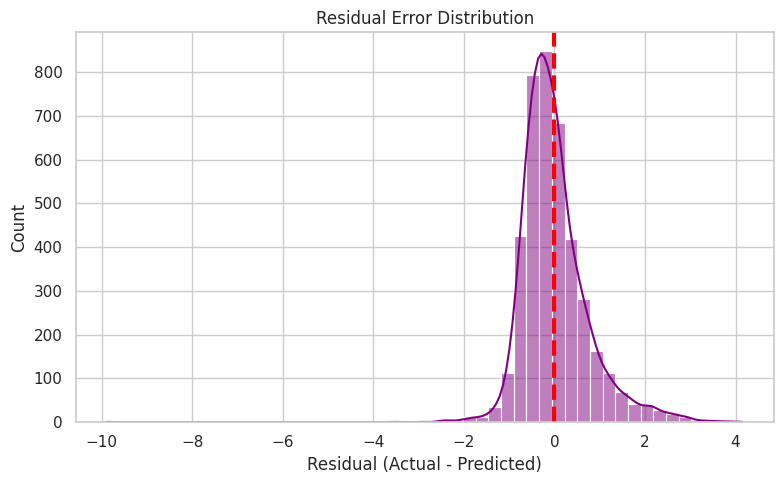

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--", lw=3.0)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Error Distribution")
plt.tight_layout()
plt.show()

7. Model Persistence (Pickle)

In [ ]:
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("Model saved to linear_regression_model.pkl")
loaded_model = pd.read_pickle("linear_regression_model.pkl")
print("Model loaded successfully:")
print(loaded_model)

Model saved to linear_regression_model.pkl
Model loaded successfully:
LinearRegression()
